In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Access Aperture4 Simulation Data

This notebook demonstrates how to access variables from Aperture4 simulation output in `/data/personal/Alex_Chen/Torus/Data_vert_B0.6_pair/`.

We use the analysis tools from `analysis_folder` and `Aperture4/external/Aperture_plotting`.

In [2]:
# Add Aperture4 python modules to path
sys.path.insert(0, '/home/aaron/Research/Aperture4/python')
sys.path.insert(0, '/home/aaron/Research/Aperture4/external/Aperture_plotting')

# Add current analysis folder to path
sys.path.insert(0, '/home/aaron/Research/Aperture4/problems/gr_2d_kerr_schild/analysis_folder')

print("Python paths configured:")
for p in sys.path[:3]:
    print(f"  {p}")

Python paths configured:
  /home/aaron/Research/Aperture4/problems/gr_2d_kerr_schild/analysis_folder
  /home/aaron/Research/Aperture4/external/Aperture_plotting
  /home/aaron/Research/Aperture4/python


In [655]:
# Import the Kerr-Schild data loader from the analysis folder
import datalib_gr_ks as ks

# Also import base datalib for reference
from datalib import Data, flag_to_species

## Define Data Directory and Inspect Contents

The simulation data is stored in `/data/personal/Alex_Chen/Torus/Data_vert_B0.6_pair/`.

In [656]:
# Define the data directory
data_dir = "/data/personal/Alex_Chen/Torus/Data_vert_B0.6_pair/"

# Check what files are available
import glob
fld_files = sorted(glob.glob(os.path.join(data_dir, "fld.*.h5")))[:5]
ptc_files = sorted(glob.glob(os.path.join(data_dir, "ptc.*.h5")))[:5]

print(f"Data directory: {data_dir}")
print(f"\nFirst 5 field files:")
for f in fld_files:
    print(f"  {os.path.basename(f)}")
print(f"\nFirst 5 particle files:")
for f in ptc_files:
    print(f"  {os.path.basename(f)}")

# Check for grid and config files
print(f"\nGrid file exists: {os.path.exists(os.path.join(data_dir, 'grid.h5'))}")
print(f"Config file exists: {os.path.exists(os.path.join(data_dir, 'config.toml'))}")

Data directory: /data/personal/Alex_Chen/Torus/Data_vert_B0.6_pair/

First 5 field files:
  fld.00000.h5
  fld.00001.h5
  fld.00002.h5
  fld.00003.h5
  fld.00004.h5

First 5 particle files:
  ptc.00000.h5
  ptc.00001.h5
  ptc.00002.h5
  ptc.00003.h5
  ptc.00004.h5

Grid file exists: True
Config file exists: True


## Load Simulation Data with `DataKerrSchild`

We use the `DataKerrSchild` class from `datalib_gr_ks.py` to load the simulation data. This class:
- Reads the configuration from `config.toml`
- Loads the grid from `grid.h5`
- Sets up Kerr-Schild metric quantities
- Provides lazy loading of field and particle variables

In [657]:
# Load the simulation data
print("Loading data... this may take a moment")
data = ks.DataKerrSchild(data_dir)

print(f"\nData loaded successfully!")
print(f"Black hole spin (a): {data.a}")
print(f"Outer horizon radius (rH): {data.rH}")
print(f"Number of field steps: {len(data.fld_steps)}")
print(f"Field steps range: {data.fld_steps[0]} to {data.fld_steps[-1]}")
print(f"Number of particle steps: {len(data.ptc_steps)}")
print(f"Particle steps range: {data.ptc_steps[0]} to {data.ptc_steps[-1]}")

# Show configuration parameters
print(f"\nConfiguration keys:")
for key in data.conf.keys():
    print(f"  {key}: {data.conf[key]}")

Loading data... this may take a moment


/home/aaron/Research/Aperture4/problems/gr_2d_kerr_schild/analysis_folder/datalib_gr_ks.py:79: RuntimeWarning: divide by zero encountered in divide
  return 1.0/Sigma(r,th,a)/np.sin(th)**2



Data loaded successfully!
Black hole spin (a): 0.998
Outer horizon radius (rH): 1.0632139225171164
Number of field steps: 2649
Field steps range: 0 to 2648
Number of particle steps: 2649
Particle steps range: 0 to 2648

Configuration keys:
  log_level: 0
  dt: 0.00025
  max_steps: 12000000
  fld_output_interval: 4000
  ptc_output_interval: 4000
  snapshot_interval: 40000
  rho_interval: 1
  max_ptc_num: 300000000
  max_ph_num: 100000000
  ptc_buffer_size: 10000000
  ph_buffer_size: 10000000
  ptc_segment_size: 20000000
  ph_segment_size: 20000000
  max_tracked_num: 4000000
  current_smoothing: 5
  tracked_fraction: 0.01
  q_e: 1.0
  bh_spin: 0.998
  use_implicit: True
  implicit_beta: 0.53
  ranks: [1, 4]
  N: [4096, 4096]
  size: [4.45, 3.141592654]
  lower: [0.0, 0.0]
  guard: [2, 2]
  periodic_boundary: [False, False]
  damping_length: 64
  damping_coef: 0.005
  damping_length_horizon: 16
  damping_coef_horizon: 0.01
  damp_to_background: True
  downsample: 2
  output_dir: Data_ver

## Access and Inspect Available Variables

The `DataKerrSchild` class provides access to field data, particle data, mesh data, and computed quantities.

In [658]:
# List all available variable keys
print("Available field keys:")
print(data._fld_keys)

print("\nAvailable particle keys:")
print(data._ptc_keys)

print("\nAvailable mesh keys:")
print(data._mesh_keys)

# Access a field variable (lazy loading - only loads when accessed)
print("\n--- Accessing field variables ---")
print(f"Rho_e shape: {data.Rho_e.shape}")
print(f"Rho_p shape: {data.Rho_p.shape}")
print(f"E1 shape: {data.E1.shape}")
print(f"B1 shape: {data.B1.shape}")

# Access computed quantities
print("\n--- Accessing computed quantities ---")
print(f"plasma_beta shape: {data.plasma_beta.shape}")
print(f"n_proper shape: {data.n_proper.shape}")

# Access mesh coordinates
print("\n--- Mesh coordinates ---")
print(f"x1 (R = r*sin(theta)) shape: {data.x1.shape}")
print(f"x2 (z = r*cos(theta)) shape: {data.x2.shape}")
print(f"_rv (r) shape: {data._rv.shape}")
print(f"_thetav (theta) shape: {data._thetav.shape}")

Available field keys:
['B1', 'B2', 'B3', 'B_sqr', 'Bmag', 'DdotB', 'E1', 'E2', 'E3', 'E_sqr', 'J01', 'J02', 'J03', 'J1', 'J2', 'J3', 'Jmag', 'Rho_e', 'Rho_p', 'Rho_ph', 'Rho_total', 'auxE1', 'auxE2', 'auxE3', 'auxH1', 'auxH2', 'auxH3', 'divB', 'divE', 'flux', 'flux_e1', 'flux_e2', 'flux_e3', 'flux_p1', 'flux_p2', 'flux_p3', 'flux_ph1', 'flux_ph2', 'flux_ph3', 'num_e', 'num_p', 'num_ph', 'pair_produced', 'photon_produced', 'step', 'stress_e00', 'stress_e01', 'stress_e02', 'stress_e03', 'stress_e11', 'stress_e12', 'stress_e13', 'stress_e22', 'stress_e23', 'stress_e33', 'stress_p00', 'stress_p01', 'stress_p02', 'stress_p03', 'stress_p11', 'stress_p12', 'stress_p13', 'stress_p22', 'stress_p23', 'stress_p33', 'stress_ph00', 'stress_ph01', 'stress_ph02', 'stress_ph03', 'stress_ph11', 'stress_ph12', 'stress_ph13', 'stress_ph22', 'stress_ph23', 'stress_ph33', 'time', 'fluxB', 'Dd1', 'Dd2', 'Dd3', 'D', 'Bd1', 'Bd2', 'Bd3', 'B', 'Ed1', 'Ed2', 'Ed3', 'Hd1', 'Hd2', 'Hd3', 'sigma', 'flux_upper', 'f

/home/aaron/Research/Aperture4/problems/gr_2d_kerr_schild/analysis_folder/datalib_gr_ks.py:318: RuntimeWarning: invalid value encountered in divide
  b1 = -u_lower[...,0] * B[...,1] / alpha_val - (u_lower[...,2] * E[...,3] - u_lower[...,3] * E[...,2]) / alpha_val / sqrt_gm
/home/aaron/Research/Aperture4/problems/gr_2d_kerr_schild/analysis_folder/datalib_gr_ks.py:319: RuntimeWarning: invalid value encountered in divide
  b2 = -u_lower[...,0] * B[...,2] / alpha_val - (u_lower[...,3] * E[...,1] - u_lower[...,1] * E[...,3]) / alpha_val / sqrt_gm
/home/aaron/Research/Aperture4/problems/gr_2d_kerr_schild/analysis_folder/datalib_gr_ks.py:320: RuntimeWarning: invalid value encountered in divide
  b3 = -u_lower[...,0] * B[...,3] / alpha_val - (u_lower[...,1] * E[...,2] - u_lower[...,2] * E[...,1]) / alpha_val / sqrt_gm
/home/aaron/Research/Aperture4/problems/gr_2d_kerr_schild/analysis_folder/datalib_gr_ks.py:345: RuntimeWarning: invalid value encountered in divide
  b_upper = self.frf_B / bnorm

plasma_beta shape: (2048, 2048)
n_proper shape: (2048, 2048)

--- Mesh coordinates ---
x1 (R = r*sin(theta)) shape: (2048, 2048)
x2 (z = r*cos(theta)) shape: (2048, 2048)
_rv (r) shape: (2048, 2048)
_thetav (theta) shape: (2048, 2048)


## Extract Fields into NumPy Arrays

You can extract any field variable into a NumPy array for further analysis or custom visualization.

In [659]:
# Extract specific fields into numpy arrays
rho_e = data.Rho_e
rho_p = data.Rho_p
E1 = data.E1
B1 = data.B1
B2 = data.B2
B3 = data.B3

# Computed quantities
beta = data.plasma_beta
n_proper = data.n_proper

# Get coordinates
R = data.x1  # cylindrical radius = r * sin(theta)
z = data.x2  # height = r * cos(theta)

print("Extracted arrays:")
print(f"  rho_e: shape={rho_e.shape}, min={np.min(rho_e):.3e}, max={np.max(rho_e):.3e}")
print(f"  rho_p: shape={rho_p.shape}, min={np.min(rho_p):.3e}, max={np.max(rho_p):.3e}")
print(f"  E1: shape={E1.shape}, min={np.min(E1):.3e}, max={np.max(E1):.3e}")
print(f"  B1: shape={B1.shape}, min={np.min(B1):.3e}, max={np.max(B1):.3e}")
print(f"  plasma_beta: shape={beta.shape}, min={np.min(beta):.3e}, max={np.max(beta):.3e}")
print(f"  n_proper: shape={n_proper.shape}, min={np.min(n_proper):.3e}, max={np.max(n_proper):.3e}")

# You can also compute your own quantities
B_magnitude = np.sqrt(B1**2 + B2**2 + B3**2)
print(f"\nCustom computed B_magnitude: shape={B_magnitude.shape}, min={np.min(B_magnitude):.3e}, max={np.max(B_magnitude):.3e}")

Extracted arrays:
  rho_e: shape=(2048, 2048), min=-1.175e+03, max=0.000e+00
  rho_p: shape=(2048, 2048), min=0.000e+00, max=1.174e+03
  E1: shape=(2048, 2048), min=-1.102e-01, max=9.723e-02
  B1: shape=(2048, 2048), min=-5.931e-01, max=5.931e-01
  plasma_beta: shape=(2048, 2048), min=nan, max=nan
  n_proper: shape=(2048, 2048), min=0.000e+00, max=2.191e+03

Custom computed B_magnitude: shape=(2048, 2048), min=6.949e-03, max=6.898e-01


## Load Different Time Steps

You can load different time steps using `load_fld()` for field data and `load_ptc()` for particle data.

In [660]:
# Example: Load a different field step
step_to_load = data.fld_steps[10]  # Load the 11th step
print(f"Loading field step: {step_to_load}")
data.load_fld(step_to_load)

# Now data.Rho_e etc. will return values from the newly loaded step
rho_e_new = data.Rho_e
print(f"New rho_e shape: {rho_e_new.shape}")
print(f"New rho_e min: {np.min(rho_e_new):.3e}, max: {np.max(rho_e_new):.3e}")

# Load back the first step
data.load_fld(data.fld_steps[0])
print(f"\nReloaded initial step: {data.fld_steps[0]}")

# Time series example: get a time series of a field quantity
print("\n--- Time series example ---")
print("To get a time series, you can use data.time_series_fld('Rho_e')")
print("This returns a list of arrays for each field step.")
print(f"Total field steps available: {len(data.fld_steps)}")
print(f"Steps: {data.fld_steps[:5]} ... {data.fld_steps[-5:]}")

Loading field step: 10
New rho_e shape: (2048, 2048)
New rho_e min: -1.362e+03, max: 0.000e+00

Reloaded initial step: 0

--- Time series example ---
To get a time series, you can use data.time_series_fld('Rho_e')
This returns a list of arrays for each field step.
Total field steps available: 2649
Steps: [0, 1, 2, 3, 4] ... [2644, 2645, 2646, 2647, 2648]


# Calculating Thermal Synchrotron Emission

## Mathematical Background

Starting from the thermal electron distribution

$$
N(\gamma)=\frac{n\gamma^2\beta e^{-\gamma/\theta_e}}{\theta_e K_2(\theta_e^{-1})},
$$

and the emissivity

$$
j^{\alpha\beta}=\int_0^\infty N(\gamma)\,\epsilon^{\alpha\beta}\,d\gamma,
$$

where

- The single-particle emissivity is
  $$
  \epsilon^{\alpha\beta}=\frac{\sqrt{3}e^2}{8\pi c}\nu_B\sin\theta_B\,H^{\alpha\beta}(\nu,\theta_B),
  $$
  with
  $$
  H^{11}=F\!\left(\frac{\nu}{\nu_c}\right)-G\!\left(\frac{\nu}{\nu_c}\right),\qquad
  H^{22}=F\!\left(\frac{\nu}{\nu_c}\right)+G\!\left(\frac{\nu}{\nu_c}\right),\qquad
  H^{12}=-H^{21}=\frac{4i\cot\theta_B}{3\gamma}H\!\left(\frac{\nu}{\nu_c}\right).
  $$

- $\gamma$ and $\beta$ are the electron Lorentz factor and corresponding velocity factor, while the dimensionless electron temperature is
  $$
  \theta_e=\frac{kT}{mc^2}.
  $$

- The emitted frequency is $\nu$, with
  $$
  \nu_c=\frac{3}{2}\nu_B\sin\theta_B\,\gamma^2,\qquad
  \nu_B=\frac{eB}{2\pi mc}.
  $$

- The synchrotron functions are
  $$
  F(x)=x\int_x^\infty K_{5/3}(y)\,dy,\qquad
  G(x)=xK_{2/3}(x),\qquad
  H(x)=\int_x^\infty K_{1/3}(y)\,dy+xK_{1/3}(x).
  $$

Since we only care about intensity (and not polarization), we need only

$$
j_I=j^{22}+j^{11}.
$$

Following a very similar process, but without the earlier two assumptions, we can follow my notes (which are still probably off by a factor of $2\pi$ compared to Dexter) to obtain

$$
j_I=\frac{1}{2\pi}\frac{ne^2}{c\sqrt{3}\,K_2(\theta_e^{-1})\,\theta_e}\,\nu\,I_I(x),
$$

where

$$
I_I(x)=\frac{1}{x}\int_{1/\theta_e}^\infty F\!\left(\frac{x}{z^2}\right)z\sqrt{z^2\theta_e^2-1}\,e^{-z}\,dz,
\qquad
x=\frac{\nu}{\nu_c'},
\qquad
\nu_c'=\frac{\nu_c}{z^2} = \frac{3}{2}\nu_B \sin(\theta_B)\theta_e^2.
$$

Note that I drop the $2\pi$ in further calculations to match Dexter

## Theoretical Calculation

### Starting Stuff

In [38]:
from scipy.integrate import quad, quad_vec
from scipy.special import kv
from scipy.interpolate import CubicSpline
from scipy.optimize import minimize_scalar
from scipy.optimize import curve_fit

### Starting Stuff

In [3]:
#Constants
c = 3e10 #cm/s
m_e = 9.11e-28 #g
q_e = 4.8e-10 #esu

In [5]:
#Chosen values
n = 1e7 # 1/cm^3
B = 10. # Gauss
theta_e = 1
theta_B = np.pi/3.

#nu/nu_c' min and max values
minnuRel = 1e-4; maxnuRel = 1e4
# minnuRel = 1e-5; maxnuRel = 1e7

In [37]:
#Basic Functions
def get_nuB(B):
    """ Magnetogryation frequency """
    return q_e*B/(2.*np.pi*m_e*c)

def get_nuc(B, gamma, theta_B):
    """ Characteristic synchrotron frequency """
    return 1.5*get_nuB(B)*np.sin(theta_B)*gamma*gamma

def get_nuc_prime(B, theta_e, theta_B):
    """ Characteristic synchrotron frequency (primed) """
    return 1.5*get_nuB(B)*np.sin(theta_B)*theta_e*theta_e

def angle(theta): return 180.*theta/np.pi

def normed(arr): return arr/max(arr)

In [12]:
def build_F_table(xmin=1e-6, xmax=1e6, N=20000):

    xgrid = np.logspace(np.log10(xmin), np.log10(xmax), N)
    Fgrid = np.zeros_like(xgrid)

    for i, x in enumerate(xgrid):
        val, _ = quad(lambda t: kv(5.0/3.0, x + t),  # shifted variable (stable!)
            0.0, np.inf, epsabs=1e-11, epsrel=1e-11)
        Fgrid[i] = x * val

    # remove any numerical pathologies
    mask = np.isfinite(Fgrid) & (Fgrid > 0)
    spline = CubicSpline(np.log(xgrid[mask]), np.log(Fgrid[mask]), extrapolate=True)
    def F_exact(x):
        # Clip to table domain to avoid wild extrapolation
        x = np.clip(x, xmin, xmax)
        return np.exp(spline(np.log(x)))
    return F_exact

# build once
F = build_F_table()

/tmp/ipykernel_1434644/1553136835.py:7: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  val, _ = quad(lambda t: kv(5.0/3.0, x + t),  # shifted variable (stable!)
/tmp/ipykernel_1434644/1553136835.py:7: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  val, _ = quad(lambda t: kv(5.0/3.0, x + t),  # shifted variable (stable!)


In [13]:
#Thermal Synchrotron Integral and Total Emissivity (normal)
def get_I_Islow(x, theta_e):
    def outer_integrand(z):
        def inner_integrand(u): return kv(5.0 / 3.0, u)
        inner, _ = quad(inner_integrand, x / z**2, np.inf)
        res = np.sqrt(z**2 * theta_e**2 - 1.0)*np.exp(-z)*inner/z
        return res

    result, _ = quad(outer_integrand, 1./theta_e, np.inf)
    return result

def get_jIslow(nu, n, B, theta_e, theta_B):
    nu_c = get_nuc_prime(B, theta_e, theta_B)
    x = nu/nu_c
    top = n*q_e*q_e * nu * get_I_Islow(x, theta_e)
    bot = np.sqrt(3.)*kv(2., 1/theta_e)*c * theta_e
    return top/bot

In [14]:
# Thermal Synchrotron Integral and Total Emissivity (more accurate)
def get_II_vec(x, theta_e):
    # x can be an array; vectorize the z integral with quad_vec
    x = np.atleast_1d(x)
    
    def integrand(z, x_arr):
        y = x_arr / z**2
        return F(y) * z * np.sqrt(theta_e**2 * z**2 - 1.) * np.exp(-z)
    
    result, _ = quad_vec(integrand, 1./theta_e, np.inf, args=(x,), epsabs=1e-11, epsrel=1e-11)
    return result / x

def get_jI(nu, n, B, theta_e, theta_B, nuOvernucp=[]):
    nu_c = get_nuc_prime(B, theta_e, theta_B)
    x = nu / nu_c
    if(len(nuOvernucp) != 0): x = nuOvernucp; nu = x*nu_c
    prefactor = (n * q_e**2 * nu / (np.sqrt(3.)*kv(2., 1./theta_e)*c*theta_e))
    # get_II_vec handles both scalar and array x
    return prefactor * get_II_vec(x, theta_e)

In [15]:
nuOvernucp = np.logspace(np.log10(minnuRel), np.log10(maxnuRel), 100)
nu = nuOvernucp * get_nuc_prime(B, theta_e, theta_B)

# j_Islow = np.array([jIslow(freq, n, B, theta_e, theta_B) for freq in nu])
j_I = get_jI(nu, n, B, theta_e, theta_B)

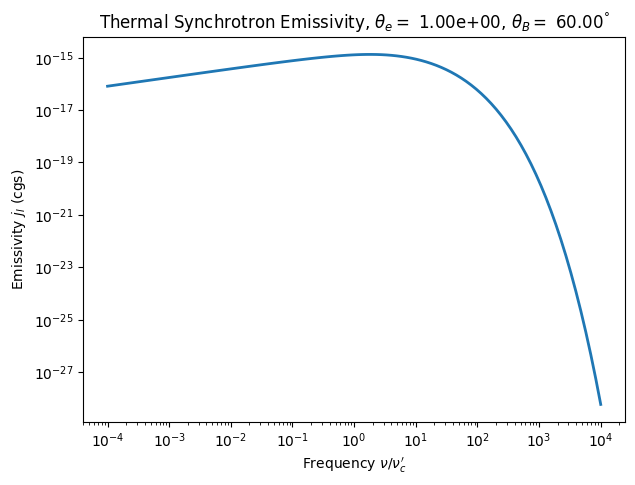

In [16]:
plt.figure(figsize=(7, 5))
plt.loglog(nuOvernucp, j_I, linewidth=2)
plt.xlabel(r"Frequency $\nu/\nu_c'$")
plt.ylabel(r'Emissivity $j_I$ (cgs)')
plt.title(fr'Thermal Synchrotron Emissivity, $\theta_e =$ {theta_e:.2e}, $\theta_B =$ {angle(theta_B):.2f}$^\degree$')
plt.show()

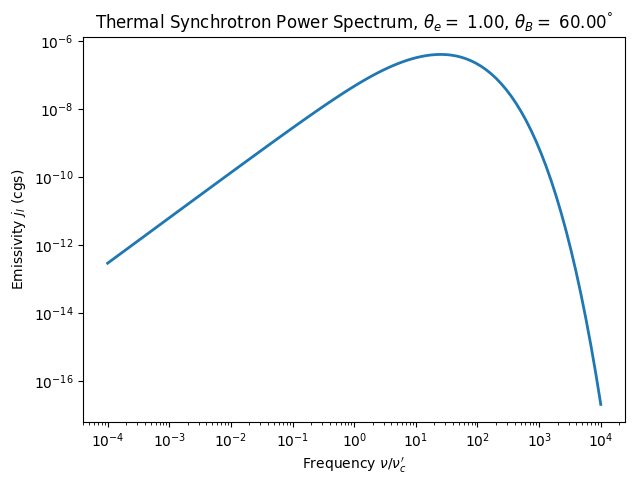

In [17]:
plt.figure(figsize=(7, 5))
plt.loglog(nuOvernucp, nu*j_I, linewidth=2)
plt.xlabel(r"Frequency $\nu/\nu_c'$")
plt.ylabel(r'Emissivity $j_I$ (cgs)')
plt.title(fr'Thermal Synchrotron Power Spectrum, $\theta_e =$ {theta_e:.2f}, $\theta_B =$ {angle(theta_B):.2f}$^\degree$')
plt.show()

### Ranging over $\theta_B$

In [18]:
theta_Bs = np.arcsin(np.linspace(0.01, 0.999, 5))
angle_Bs = angle(theta_Bs) # np.array([15., 30., 45., 60., 90.])
nus = np.array([nuOvernucp*get_nuc_prime(B, theta_e, thB) for thB in theta_Bs])
j_Is = np.array([get_jI(nus[i], n, B, theta_e, theta_Bs[i]) for i in range(len(theta_Bs))])

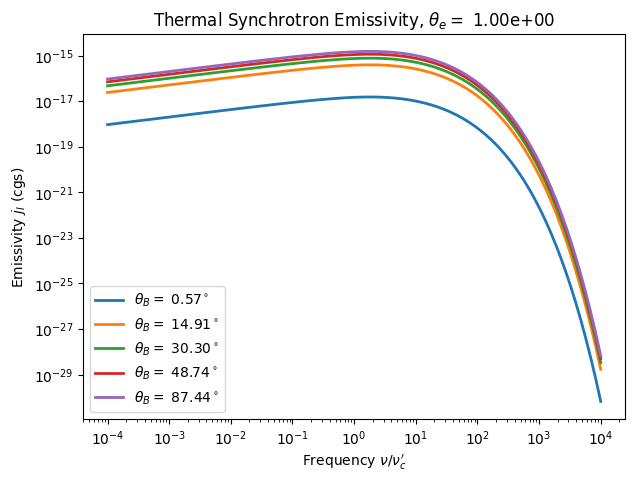

In [19]:
plt.figure(figsize=(7, 5))
[plt.loglog(nuOvernucp, j_Is[i], linewidth=2, label=fr"$\theta_B =$ {angle_Bs[i]:.2f}$^\circ$") for i in range(len(j_Is))]
plt.xlabel(r"Frequency $\nu/\nu_c'$")
plt.ylabel(r'Emissivity $j_I$ (cgs)')
plt.title(fr'Thermal Synchrotron Emissivity, $\theta_e =$ {theta_e:.2e}')
plt.legend()
plt.show()

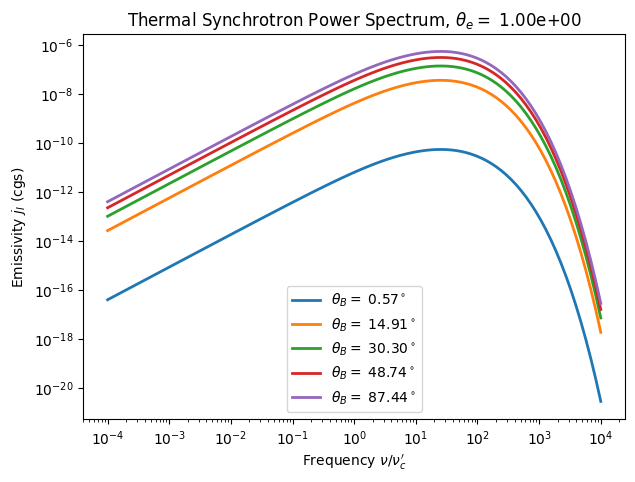

In [20]:
plt.figure(figsize=(7, 5))
[plt.loglog(nuOvernucp, nus[i]*j_Is[i], linewidth=2, label=fr"$\theta_B =$ {angle_Bs[i]:.2f}$^\circ$") for i in range(len(j_Is))]
plt.xlabel(r"Frequency $\nu/\nu_c'$")
plt.ylabel(r'Emissivity $j_I$ (cgs)')
plt.title(fr'Thermal Synchrotron Power Spectrum, $\theta_e =$ {theta_e:.2e}')
plt.legend()
plt.show()

### Finding maximums along $\theta_B$

In [21]:
# Equivalently, we find the minimum of the negative
# Precompute II(x) on a log grid once per theta_e, then reuse for any theta_B
_x_grid = np.logspace(np.log10(minnuRel), np.log10(maxnuRel), 2000)

def build_ii_cache(theta_e):
    _ii_grid = get_II_vec(_x_grid, theta_e)
    # mask non-positive / non-finite values to keep log safe
    mask = np.isfinite(_ii_grid) & (_ii_grid > 0)
    x_masked = _x_grid[mask]
    ii_masked = _ii_grid[mask]
    ii_spline = CubicSpline(np.log(x_masked), np.log(ii_masked), extrapolate=True)
    return ii_spline

def get_maxvals(theta_e, theta_B, printVals=False):
    nu_c = get_nuc_prime(B, theta_e, theta_B)
    ii_spline = build_ii_cache(theta_e)
    
    def jI_from_x(x):
        prefactor =  n * q_e**2 * (x * nu_c) / (np.sqrt(3.)*kv(2., 1/theta_e)*c*theta_e)
        # Use cached spline; clip to valid log range
        logx = np.clip(np.log(x), np.log(_x_grid[0]), np.log(_x_grid[-1]))
        return float(prefactor * np.exp(ii_spline(logx)))
    
    neg_jI = lambda x: -jI_from_x(x)
    res_emiss = minimize_scalar(neg_jI, bounds=(minnuRel, maxnuRel), method='bounded')
    neg_PS = lambda x: -(x * nu_c) * jI_from_x(x)
    res_PS = minimize_scalar(neg_PS, bounds=(minnuRel, maxnuRel), method='bounded')

    if(printVals):
        print(f"--- Emissivity + Power Spectrum Peak ---")
        print(f"x = nu/nu_c' = {res_emiss.x:.6f}, {res_PS.x:.6f}")
        print(f"Peak Value (cgs): {-res_emiss.fun:.6e}, {-res_PS.fun:.6e}")
    return -res_emiss.fun, -res_PS.fun

In [22]:
theta_e = 1.
theta_B = np.pi/3.
get_maxvals(theta_e, theta_B, True);

--- Emissivity + Power Spectrum Peak ---
x = nu/nu_c' = 1.814287, 25.305849
Peak Value (cgs): 1.321194e-15, 3.975946e-07


In [39]:
def get_peak_pair(theta_e, theta_B, ii_spline=None, get_pos=False):
    """Compute peak emissivity and power spectrum for a single (theta_e, theta_B) pair."""
    nu_c = get_nuc_prime(B, theta_e, theta_B)
    if ii_spline is None:
        ii_spline = build_ii_cache(theta_e)

    def jI_from_x(x):
        prefactor = n * q_e**2 * (x * nu_c) / (np.sqrt(3.)*kv(2., 1/theta_e)*c*theta_e)
        logx = np.clip(np.log(x), np.log(_x_grid[0]), np.log(_x_grid[-1]))
        return float(prefactor * np.exp(ii_spline(logx)))

    neg_jI = lambda x: -jI_from_x(x)
    res_emiss = minimize_scalar(neg_jI, bounds=(minnuRel, maxnuRel), method='bounded')
    neg_PS = lambda x: -(x * nu_c) * jI_from_x(x)
    res_PS = minimize_scalar(neg_PS, bounds=(minnuRel, maxnuRel), method='bounded')

    if get_pos:
        return -res_emiss.fun, -res_PS.fun, res_emiss.x, res_PS.x
    return -res_emiss.fun, -res_PS.fun

def returnPeaks(theta_es, theta_Bs, get_pos=False, get_theta_B_first=True):
    theta_e_arr = np.atleast_1d(theta_es)
    theta_B_arr = np.atleast_1d(theta_Bs)

    # Both scalar
    if theta_e_arr.size == 1 and theta_B_arr.size == 1:
        return get_peak_pair(float(theta_e_arr[0]), float(theta_B_arr[0]), get_pos=get_pos)

    # Scalar theta_e, array theta_Bs  (backward-compatible path)
    if theta_e_arr.size == 1:
        te = float(theta_e_arr[0])
        ii_spline = build_ii_cache(te)
        out = [get_peak_pair(te, float(tb), ii_spline=ii_spline, get_pos=get_pos) for tb in theta_B_arr]
        if get_pos:
            return tuple(np.array([o[i] for o in out]) for i in range(4))
        return tuple(np.array([o[i] for o in out]) for i in range(2))

    # Array theta_e, scalar theta_B
    if theta_B_arr.size == 1:
        tb = float(theta_B_arr[0])
        out = []
        for te in theta_e_arr:
            ii_spline = build_ii_cache(float(te))
            out.append(get_peak_pair(float(te), tb, ii_spline=ii_spline, get_pos=get_pos))
        if get_pos:
            return tuple(np.array([o[i] for o in out]) for i in range(4))
        return tuple(np.array([o[i] for o in out]) for i in range(2))

    # Both arrays
    n_te, n_tb = len(theta_e_arr), len(theta_B_arr)
    if get_theta_B_first:
        # output shape: (n_tb, n_te)
        if get_pos:
            j_peaks = np.empty((n_tb, n_te))
            PS_peaks = np.empty((n_tb, n_te))
            j_xpeaks = np.empty((n_tb, n_te))
            PS_xpeaks = np.empty((n_tb, n_te))
            for j, te in enumerate(theta_e_arr):
                ii_spline = build_ii_cache(float(te))
                for i, tb in enumerate(theta_B_arr):
                    j_peaks[i, j], PS_peaks[i, j], j_xpeaks[i, j], PS_xpeaks[i, j] = \
                        get_peak_pair(float(te), float(tb), ii_spline=ii_spline, get_pos=True)
            return j_peaks, PS_peaks, j_xpeaks, PS_xpeaks
        else:
            j_peaks = np.empty((n_tb, n_te))
            PS_peaks = np.empty((n_tb, n_te))
            for j, te in enumerate(theta_e_arr):
                ii_spline = build_ii_cache(float(te))
                for i, tb in enumerate(theta_B_arr):
                    j_peaks[i, j], PS_peaks[i, j] = get_peak_pair(float(te), float(tb), ii_spline=ii_spline, get_pos=False)
            return j_peaks, PS_peaks
    else:
        # output shape: (n_te, n_tb)
        if get_pos:
            j_peaks = np.empty((n_te, n_tb))
            PS_peaks = np.empty((n_te, n_tb))
            j_xpeaks = np.empty((n_te, n_tb))
            PS_xpeaks = np.empty((n_te, n_tb))
            for i, te in enumerate(theta_e_arr):
                ii_spline = build_ii_cache(float(te))
                for j, tb in enumerate(theta_B_arr):
                    j_peaks[i, j], PS_peaks[i, j], j_xpeaks[i, j], PS_xpeaks[i, j] = \
                        get_peak_pair(float(te), float(tb), ii_spline=ii_spline, get_pos=True)
            return j_peaks, PS_peaks, j_xpeaks, PS_xpeaks
        else:
            j_peaks = np.empty((n_te, n_tb))
            PS_peaks = np.empty((n_te, n_tb))
            for i, te in enumerate(theta_e_arr):
                ii_spline = build_ii_cache(float(te))
                for j, tb in enumerate(theta_B_arr):
                    j_peaks[i, j], PS_peaks[i, j] = get_peak_pair(float(te), float(tb), ii_spline=ii_spline, get_pos=False)
            return j_peaks, PS_peaks

def peak_plot(x_var, peaks, i, label_var, plot_along=None,
              sin_plot=False, logx=True, logy=True, extraLabel=""):
    """
    Plot peak emissivity / power spectrum.

    Parameters
    ----------
    x_var : float or array
        Variable on the x-axis (theta_B or theta_e).
    peaks : array or list/tuple of arrays
        Y data. 1D array, list of 1D arrays, or 2D array.
    i : int
        0 = emissivity peak, 1 = power spectrum peak.
    label_var : float or array
        Variable used for curve labels (theta_e or theta_B).
    plot_along : {None, 'x_var', 'label_var'}, optional
        For 2D ``peaks`` only: which axis slices into curves.
        * 'x_var'   – each column is a curve; x-axis is ``x_var``.
        * 'label_var' – each row is a curve; x-axis is ``label_var``.
        If None, auto-detected from shape matching.
    sin_plot : bool
        Plot sin(x_var) on the x-axis.
    logx, logy : bool
        Log scales.
    extraLabel : str or sequence
        Extra text appended to each legend entry.
    """
    x_arr = np.atleast_1d(x_var)
    label_arr = np.atleast_1d(label_var)

    # ---- decide what the variables represent (heuristic) ----
    def _is_theta_B(arr):
        return np.all((arr >= 0) & (arr <= np.pi + 0.1))

    x_is_theta_B = _is_theta_B(x_arr)
    label_is_theta_B = _is_theta_B(label_arr)

    # Override: if sin_plot=True, x_var is always theta_B and label_var is theta_e
    if sin_plot:
        x_is_theta_B = True
        label_is_theta_B = False

    # ---- normalise extraLabel ----
    if not isinstance(extraLabel, (list, tuple)):
        extraLabel = (extraLabel,) * max(len(label_arr), 1)
    else:
        extraLabel = tuple(extraLabel)

    # ---- unpack peaks ----
    peaks_is_list = isinstance(peaks, (list, tuple))
    if peaks_is_list:
        # list/tuple of 1-D arrays  (e.g. [actual, fit])
        curves = [np.atleast_1d(p) for p in peaks]
        x_data = x_arr
        labels = label_arr
    else:
        peaks_arr = np.asarray(peaks)
        if peaks_arr.ndim < 2:
            # single 1-D curve
            if len(x_arr) == 1 and len(label_arr) > 1:
                # scalar x, array label  -> swap so array is on the axis
                x_arr, label_arr = label_arr, x_arr
                x_is_theta_B, label_is_theta_B = label_is_theta_B, x_is_theta_B
            curves = [np.atleast_1d(peaks_arr)]
            x_data = x_arr
            labels = label_arr
        else:
            # 2-D array  -> both x_var and label_var are arrays
            if plot_along is None:
                if len(x_arr) == peaks_arr.shape[0]:
                    plot_along = 'x_var'
                elif len(x_arr) == peaks_arr.shape[1]:
                    plot_along = 'label_var'
                else:
                    raise ValueError(
                        "Cannot auto-determine plot_along from shapes. "
                        "Pass plot_along='x_var' or plot_along='label_var'."
                    )

            if plot_along == 'label_var':
                # want label_var on x-axis, curves for each x_var
                if peaks_arr.shape == (len(x_arr), len(label_arr)):
                    peaks_arr = peaks_arr.T
                x_arr, label_arr = label_arr, x_arr
                x_is_theta_B, label_is_theta_B = label_is_theta_B, x_is_theta_B

            # now peaks_arr should be (len(x_arr), len(label_arr))
            if peaks_arr.shape != (len(x_arr), len(label_arr)):
                if peaks_arr.shape == (len(label_arr), len(x_arr)):
                    peaks_arr = peaks_arr.T
                else:
                    raise ValueError(
                        f"peaks shape {peaks_arr.shape} incompatible with "
                        f"({len(x_arr)}, {len(label_arr)})"
                    )

            curves = [peaks_arr[:, j] for j in range(peaks_arr.shape[1])]
            x_data = x_arr
            labels = label_arr

    # ---- plot ----
    plt.figure(figsize=(7, 5))
    if logx:
        plt.xscale('log')
    if logy:
        plt.yscale('log')

    x_plot = np.sin(x_data) if sin_plot else x_data
    x_label_str = r"$\theta_B$" if x_is_theta_B else r"$\theta_e$"
    label_prefix = r"$\theta_B =$ " if label_is_theta_B else r"$\theta_e =$ "

    for j, curve in enumerate(curves):
        val = float(labels[j]) if np.ndim(labels[j]) == 0 else float(labels[j].flat[0])
        if label_is_theta_B:
            lbl = label_prefix + f"{np.degrees(val):.1f}°" + str(extraLabel[j])
        else:
            lbl = label_prefix + f"{val:.2f}" + str(extraLabel[j])
        plt.plot(x_plot, curve, lw=2, label=lbl, marker="o")

    plt.xlabel(r"$\sin \theta_B$" if sin_plot else x_label_str)
    lbl_title = ["Peak emissivity $j_I$", "Power Law Peak"]
    plt.ylabel(f'{lbl_title[i]} (cgs)')
    plt.legend()
    plt.show()


In [24]:
theta_Bs = np.flip(np.arcsin(np.logspace(-2, np.log10(0.999), 20)))
j_peaks, PS_peaks = returnPeaks(theta_e, theta_Bs)

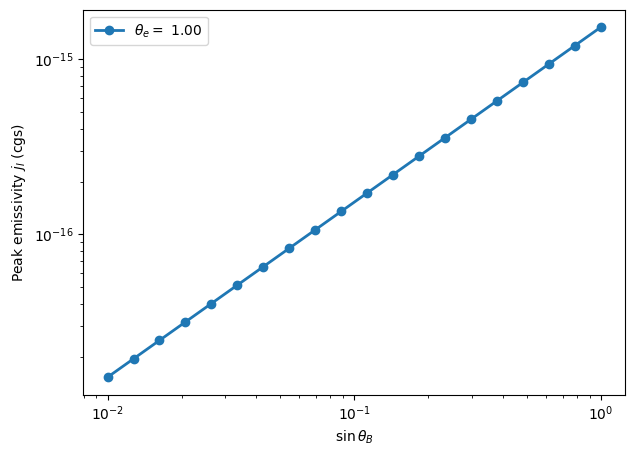

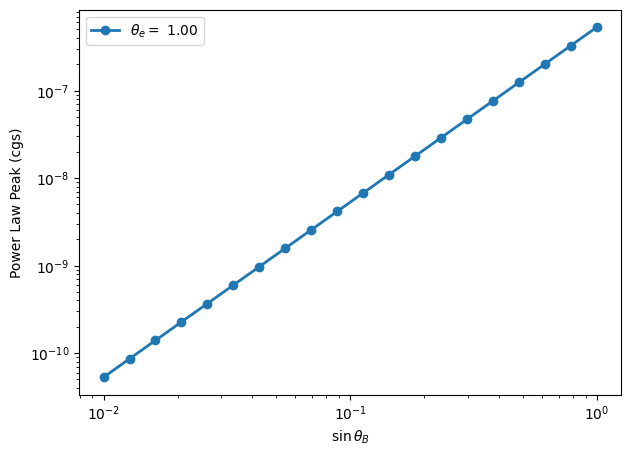

In [25]:
peak_plot(theta_Bs, j_peaks,  0, theta_e, sin_plot=True, logx=True, logy=True)
peak_plot(theta_Bs, PS_peaks, 1, theta_e, sin_plot=True, logx=True, logy=True)

#### Fitting along $\theta_B$

In [26]:
# logthB = np.log10(theta_Bs)
logsinthB = np.log10(np.sin(theta_Bs))
y_j, y_PS = np.log10(j_peaks), np.log10(PS_peaks)
[slope_j, b_j], [ss_res_j,], _, _, _ =   np.polyfit(logsinthB, y_j,  deg=1, full=True)
[slope_PS, b_PS], [ss_res_PS,], _, _, _ = np.polyfit(logsinthB, y_PS, deg=1, full=True)

j_peaks_fit = np.sin(theta_Bs)**slope_j * 10**b_j
PS_peaks_fit = np.sin(theta_Bs)**slope_PS * 10**b_PS

In [27]:
R2 = lambda ss_res, y: 1. - ss_res/np.sum((y - np.mean(y))**2)
print(fr"Slope, intercept, R^2 values")
print(fr"j:  {slope_j:.2f}, {b_j:.2f}, {R2(ss_res_j, y_j):.3f}")
print(fr"PS: {slope_PS:.2f}, {b_PS:.2f}, {R2(ss_res_PS, y_PS):.3f}")

Slope, intercept, R^2 values
j:  1.00, -14.82, 1.000
PS: 2.00, -6.28, 1.000


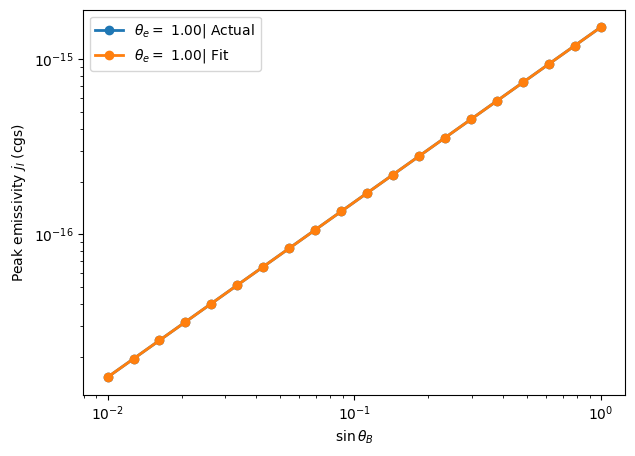

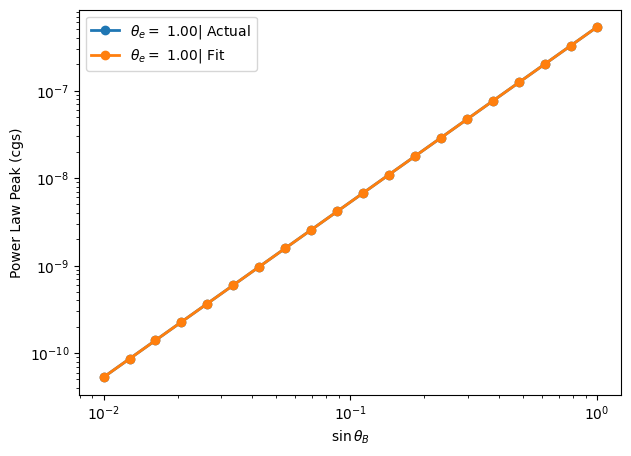

In [28]:
#Should I just ignore the last few points to the fit?
peak_plot(theta_Bs, [j_peaks, j_peaks_fit],   0, [theta_e, theta_e], sin_plot=True, logx=True, logy=True, extraLabel=["| Actual", "| Fit"])
peak_plot(theta_Bs, [PS_peaks, PS_peaks_fit], 1, [theta_e, theta_e], sin_plot=True, logx=True, logy=True, extraLabel=["| Actual", "| Fit"])

### Ranging over $\theta_e$

In [29]:
theta_es = np.logspace(-2, 3, 8)
theta_B = np.pi/3.; angle_B = angle(theta_B)
nus2 = np.array([nuOvernucp*get_nuc_prime(B, th_e, theta_B) for th_e in theta_es])
j_Is2 = np.array([get_jI(nus2[i], n, B, theta_es[i], theta_B) for i in range(len(theta_es))])

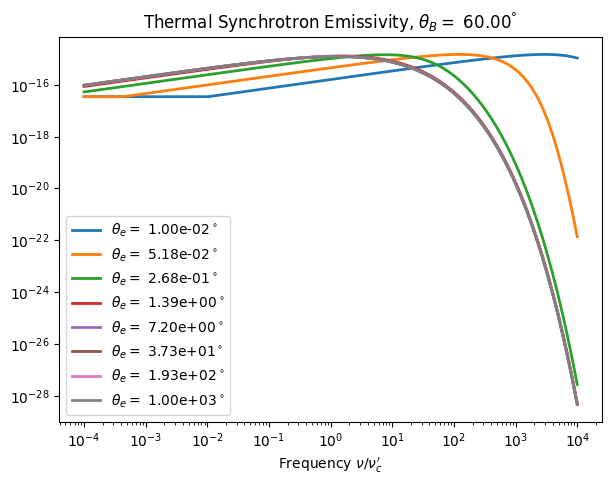

In [32]:
plt.figure(figsize=(7, 5))
[plt.loglog(nuOvernucp, j_Is2[i], linewidth=2, label=fr"$\theta_e =$ {theta_es[i]:.2e}$^\circ$") for i in range(len(j_Is2))]
plt.xlabel(r"Frequency $\nu/\nu_c'$")
# plt.ylabel(r'Emissivity $j_I$ (cgs)')
plt.title(fr'Thermal Synchrotron Emissivity, $\theta_B =$ {angle_B:.2f}$^\degree$')
plt.legend()
plt.show()

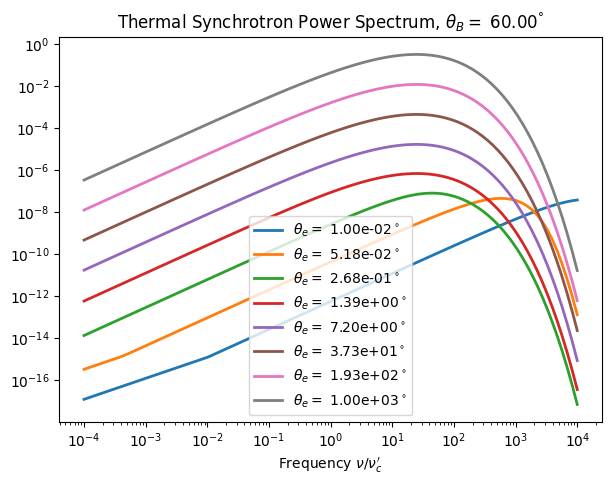

In [33]:
plt.figure(figsize=(7, 5))
[plt.loglog(nuOvernucp, nus2[i]*j_Is2[i], linewidth=2, label=fr"$\theta_e =$ {theta_es[i]:.2e}$^\circ$") for i in range(len(j_Is2))]
plt.xlabel(r"Frequency $\nu/\nu_c'$")
# plt.ylabel(r'Emissivity $j_I$ (cgs)')
plt.title(fr'Thermal Synchrotron Power Spectrum, $\theta_B =$ {angle_B:.2f}$^\degree$')
plt.legend()
plt.show()

### Finding maximums along $\theta_e$

In [ ]:
theta_es = np.logspace(-2, 3, 20)
theta_B = np.pi/3.; angle_B = angle(theta_B)

j_peaks2, PS_peaks2 = returnPeaks(theta_es, theta_B)

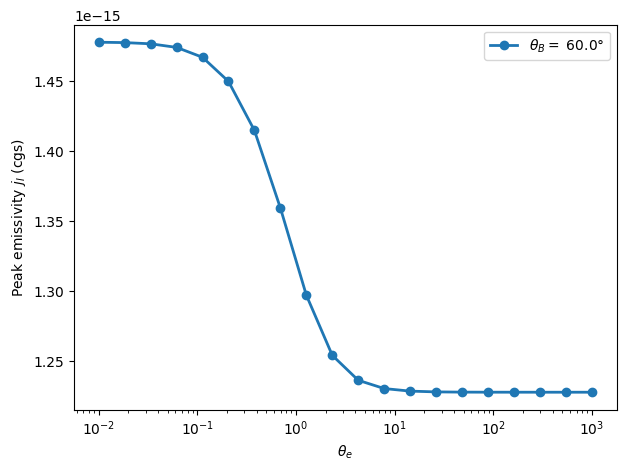

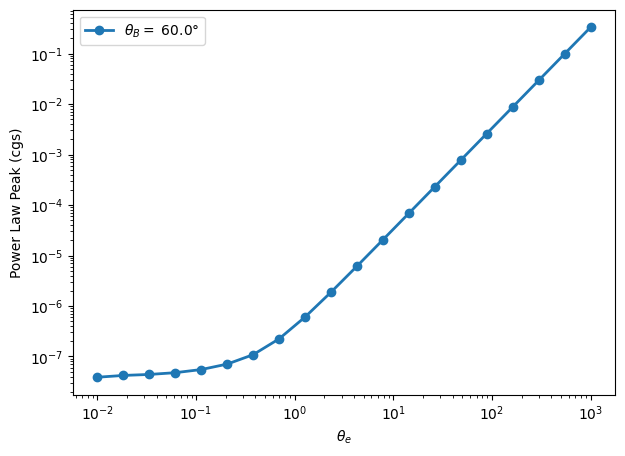

In [40]:
peak_plot(theta_es, j_peaks2,  0, theta_B, sin_plot=False, logx=True, logy=False)
peak_plot(theta_es, PS_peaks2, 1, theta_B, sin_plot=False, logx=True, logy=True)

Why do we not have that? Built in relativistic assumption that generates that angular theta_B dependence?

#### Flipped plots

In [ ]:
#More points so we can get a better fit
theta_es = np.logspace(-2, 3, 30)
# theta_es = np.linspace(1e-2, 1e3, 30)
theta_Bs = np.flip(np.arcsin(np.logspace(-2, np.log10(0.999), 20)))
# Call once with both arrays to leverage ii_spline caching (30 cache builds instead of 600)
peakPeaksP = np.array(returnPeaks(theta_es, theta_Bs, get_pos=True, get_theta_B_first=False))
peakPeaksPFlipped = peakPeaksP.transpose((0, 2, 1))

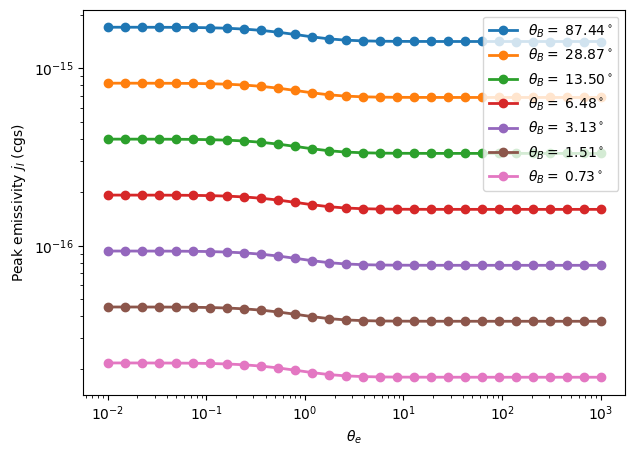

In [42]:
#Flipped plot
plt.figure(figsize=(7, 5))
[plt.plot(theta_es, peakPeaksPFlipped[0][i], lw=2, label=fr"$\theta_B =$ {angle(theta_Bs[i]):.2f}$^\circ$", marker="o") for i in range(0,len(theta_Bs),3)]
plt.yscale('log'); plt.xscale('log')
plt.xlabel(r"$\theta_e$"); plt.ylabel(fr'Peak emissivity $j_I$ (cgs)')
plt.legend(); plt.show()

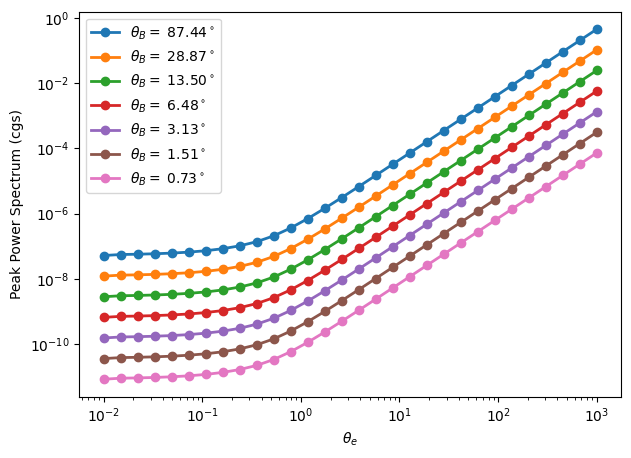

In [43]:
#Flipped plot
plt.figure(figsize=(7, 5))
[plt.plot(theta_es, peakPeaksPFlipped[1][i], lw=2, label=fr"$\theta_B =$ {angle(theta_Bs[i]):.2f}$^\circ$", marker="o") for i in range(0,len(theta_Bs),3)]
plt.yscale('log'); plt.xscale('log')
plt.xlabel(r"$\theta_e$"); plt.ylabel(fr'Peak Power Spectrum (cgs)')
plt.legend(); plt.show()

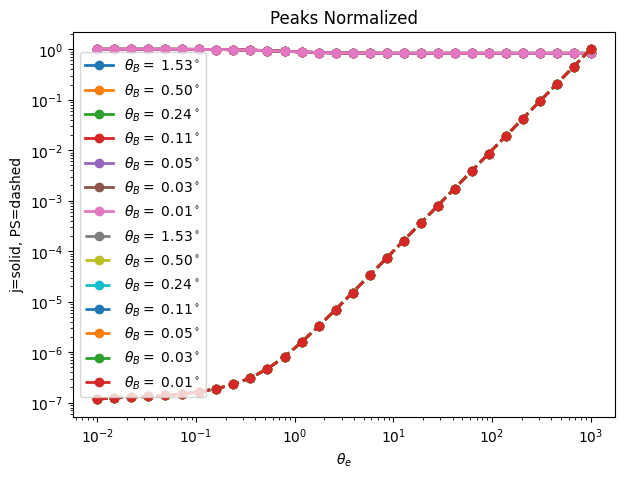

In [46]:
plt.figure(figsize=(7, 5))
[plt.plot(theta_es, normed(peakPeaksPFlipped[0][i]), lw=2, label=fr"$\theta_B =$ {theta_Bs[i]:.2f}$^\circ$", marker="o") for i in range(0,len(theta_Bs),3)]
[plt.plot(theta_es, normed(peakPeaksPFlipped[1][i]), lw=2, label=fr"$\theta_B =$ {theta_Bs[i]:.2f}$^\circ$", marker="o",ls="dashed") for i in range(0,len(theta_Bs),3)]
plt.xlabel(r"$\theta_e$"); plt.ylabel(fr'j=solid, PS=dashed')
plt.yscale('log'); plt.xscale('log')
plt.title("Peaks Normalized")
plt.legend(); plt.show()

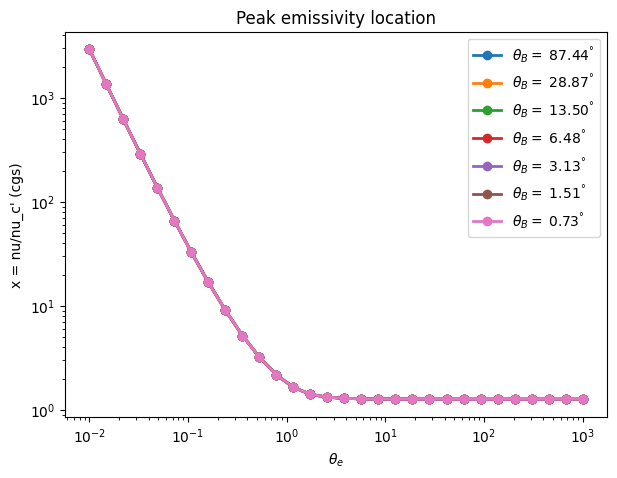

In [47]:
plt.figure(figsize=(7, 5))
[plt.plot(theta_es, peakPeaksPFlipped[2][i], lw=2, label=fr"$\theta_B =$ {angle(theta_Bs[i]):.2f}$^\degree$", marker="o") for i in range(0,len(theta_Bs),3)]
plt.yscale('log'); plt.xscale('log')
plt.xlabel(r"$\theta_e$"); plt.ylabel(fr"x = nu/nu_c' (cgs)")
plt.title("Peak emissivity location")
plt.legend(); plt.show()

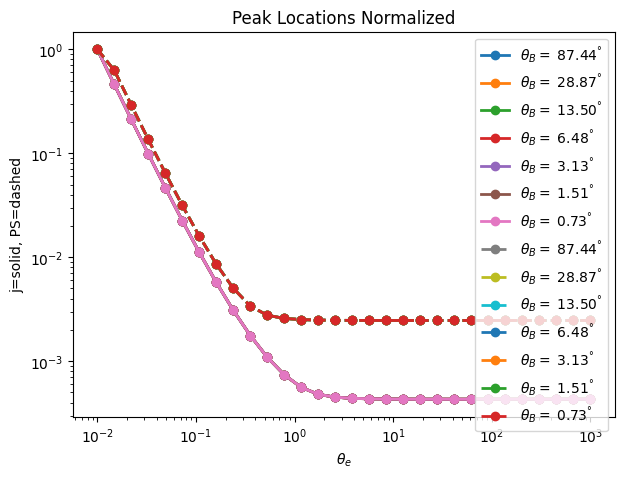

In [48]:
plt.figure(figsize=(7, 5))
[plt.plot(theta_es, normed(peakPeaksPFlipped[2][i]), lw=2, label=fr"$\theta_B =$ {angle(theta_Bs[i]):.2f}$^\degree$", marker="o") for i in range(0,len(theta_Bs),3)]
[plt.plot(theta_es, normed(peakPeaksPFlipped[3][i]), lw=2, label=fr"$\theta_B =$ {angle(theta_Bs[i]):.2f}$^\degree$", marker="o",ls="dashed") for i in range(0,len(theta_Bs),3)]
plt.yscale('log'); plt.xscale('log')
plt.xlabel(r"$\theta_e$"); plt.ylabel(fr'j=solid, PS=dashed')
plt.title("Peak Locations Normalized")
plt.legend(); plt.show()

#### Fitting along $\theta_e$

We actually don't do this (at least not right now)

#### Finally getting an approxmation for $j$

In [125]:
nChange = 1e7 # 1/cm^3
BChange = 10. # Gauss
theta_eChange = 10.
theta_BChange = np.pi/3.
C0 = (nChange * q_e**2 / (np.sqrt(3.)*kv(2., 1./theta_eChange)*c*theta_eChange))

In [160]:
#Function forms
model_names = ['Basic F', 'x-axis stretch power law F', 'x-axis stretch F', 'extra power law F', 'power law w/ exp']
model_paramNames= ["nu0", "C", "shift", "p"]
model_forms = ['C*C0*F(nu/nu0 - shift)', ' C*C0*(nu/nu0)^p * F((nu/nu0)^p - shift)', 'C*C0*F((nu/nu0)^p - shift)',
            'C*C0*(nu/nu0 - shift)^p * F(nu/nu0 - shift)',
            'C*(nu/nu0 - shift)^p * exp(-nu/nu0 + shift)']


In [161]:
def emis_model(log_nu, log_nu0, C, shift):
    """Basic F-based model."""
    return C0 * C * F(10.0**(log_nu - log_nu0) - shift)

def emis_model_stretch_in(log_nu, log_nu0, C, shift, p):
    """F model with shift inside the power: F((nu/nu0 - shift)^p)."""
    x = (10.0**(log_nu - log_nu0) - shift)**p
    return C0 * C * F(x)

def emis_model_stretch_out(log_nu, log_nu0, C, shift, p):
    """F model with shift outside the power: F((nu/nu0)^p - shift)."""
    x = (10.0**(log_nu - log_nu0))**p - shift
    return C0 * C * F(x)

def emis_model_stretch_out_noP(log_nu, log_nu0, C, shift, p):
    """F model with argument (nu/nu0)^p - shift but NO prefactor (nu/nu0)^p."""
    x = (10.0**(log_nu - log_nu0))**p - shift
    return C0 * C * F(x)

def emis_model_powerF(log_nu, log_nu0, C, shift, p):
    """F-based model with an extra power-law factor (nu/nu0)^p."""
    x = 10.0**(log_nu - log_nu0)
    return C0 * C * ((x - shift)**p) * F(x - shift)

def emis_model_power_exp(log_nu, log_nu0, C, shift, p):
    """Power law with exponential cutoff and shift: (nu/nu0 - shift)^p * exp(-nu/nu0 + shift)."""
    x = 10.0**(log_nu - log_nu0)
    return C * (x - shift)**p * np.exp(-x + shift)

def get_fit(emis_model, data, ind_var, init_guess=None, bounds=None):
    x_data = np.log10(ind_var)
    y_data = np.log10(data)
    n_params = len(init_guess) if init_guess is not None else 3

    def log_model(x, *params):
        val = np.asarray(emis_model(x, *params), dtype=float)
        # replace any non-positive / non-finite with a tiny positive number
        val[~np.isfinite(val) | (val <= 0)] = 1e-300
        return np.log10(val)

    if bounds is None:
        log_nu_min = np.log10(np.min(ind_var))
        log_nu_max = np.log10(np.max(ind_var))
        if n_params == 2:
            # (log_nu0, C)
            bounds = ([log_nu_min - 4, 1e-30],
                      [log_nu_max + 4, 1e20])
        elif n_params == 3:
            # (log_nu0, C, shift_or_p)
            bounds = ([log_nu_min - 4, 1e-30, -50.0],
                      [log_nu_max + 4, 1e20,  50.0])
        elif n_params == 4:
            # (log_nu0, C, shift, extra) -- covers both stretch (p) and power (M)
            bounds = ([log_nu_min - 7, 1e-30, -20.0, -100.0],
                      [log_nu_max + 7, 1e20,   20.0,  100.0])

    popt, pcov = curve_fit(log_model, x_data, y_data, p0=init_guess, bounds=bounds,
                           maxfev=50000, method='dogbox')
    return popt, np.sqrt(np.diag(pcov))

def get_err_string(val, abs_err, typ, needExp=False):
    if needExp:
        val = 10**val
        abs_err = val * np.log(10) * abs_err
    pct = 1e2 * abs_err / abs(val) if val != 0 else np.inf
    if typ == 1: return f"{val:.2f} +/- {pct:.2f}%"
    return f"{val:.2e} +/- {pct:.2f}%"

def eval_model(emis_model_func, popt, ind_var):
    """Evaluate an emissivity model at fitted parameters."""
    return emis_model_func(np.log10(ind_var), *popt)

def print_model(i, params, errors, paramNames, style=[], needExp=[True, False, False, False]): 
    if(style==[]): style=np.zeros_like(params)
    if(needExp==[]): needExp=np.zeros_like(params)
    print(f"Function: {model_names[i]}")
    print(f"Form: {model_forms[i]}")
    errorString = [f"{get_err_string(params[j], errors[j], style[j], needExp[j])}" for j in range(len(params))]
    [print(f"{paramNames[j]} = {errorString[j]}, ", end="") for j in range(len(paramNames))]
    print()

def test_model(emis_model_func, data, ind_var, name="Model", init_guess=None, bounds=None, model_index=None):
    """
    Fit a model to the data, print results, and return parameters.
    
    Parameters
    ----------
    emis_model_func : callable
        Emissivity model function.
    data : array
        y-data to fit.
    ind_var : array
        Independent variable (frequency).
    name : str
        Model name for printing.
    init_guess : list, optional
        Initial guess. If None, auto-generated from data.
    bounds : tuple, optional
        Lower and upper bounds for parameters, passed to curve_fit.
    model_index : int, optional
        Index into model_names / model_forms for print_model formatting.
    
    Returns
    -------
    popt, errs : fitted parameters and 1-sigma uncertainties
    """
    n_params = emis_model_func.__code__.co_argcount - 1  # exclude log_nu
    
    if init_guess is None:
        # Auto-generate initial guess from data peak
        peak_idx = np.argmax(data)
        log_nu_peak = np.log10(ind_var[peak_idx])
        log_nu0_init = log_nu_peak + 1.5
        x_at_peak = 10.0**(log_nu_peak - log_nu0_init)
        
        # F-based models use C0 scaling; power_exp does not
        if "power_exp" in emis_model_func.__name__:
            C_init = data[peak_idx]
        else:
            C_init = data[peak_idx] / (C0 * F(x_at_peak))
        
        init_guess = [log_nu0_init, C_init]
        if n_params >= 3:
            init_guess.append(0.0)  # shift or p
        if n_params == 4:
            init_guess.append(1.0 if "stretch" in emis_model_func.__name__ else 0.0)
    
    popt, errs = get_fit(emis_model_func, data, ind_var, init_guess=init_guess, bounds=bounds)
    
    if model_index is not None:
        paramNames = model_paramNames[:n_params]
        print_model(model_index, popt, errs, paramNames)
    else:
        print(f"\n--- Testing {name} ---")
        print(f"Initial guess: {init_guess}")
        print(f"Fit success! popt: {popt}")
        print(f"errs: {errs}")
    
    return popt, errs

In [162]:
# Generate data to fit: thermal synchrotron emissivity for the chosen parameters
nu_c_prime = get_nuc_prime(BChange, theta_eChange, theta_BChange)
nuOvernucp = np.logspace(np.log10(minnuRel), np.log10(maxnuRel), 100)
ind_var = nuOvernucp * nu_c_prime
data = get_jI(ind_var, nChange, BChange, theta_eChange, theta_BChange)

In [163]:
# 1. Basic F-based model (3 params: log_nu0, C, shift)
popt_basic, errs_basic = test_model(emis_model, data, ind_var, name="Basic F model", model_index=0)

Function: Basic F
Form: C*C0*F(nu/nu0 - shift)
nu0 = 9.44e+11 +/- 4.01%, C = 3.03e+12 +/- 0.00%, shift = -7.33e+00 +/- 3.93%, 


In [ ]:
# 2. Stretch model (4 params: log_nu0, C, shift, p) -- shift INSIDE the power
popt_stretch_in, errs_stretch_in = test_model(emis_model_stretch_in, data, ind_var, name="Stretch F model (shift in)", model_index=1)
print()
# 2b. Stretch model -- shift OUTSIDE the power
# Tighten bounds so shift cannot go positive (avoids sign-flip jump at low frequency)
log_nu_min, log_nu_max = np.log10(np.min(ind_var)), np.log10(np.max(ind_var))
bounds_out0 = ([log_nu_min - 7, 1e-30, -20.0, -100],
              [log_nu_max + 7, 1e20,   20.0,  100])
bounds_out = ([log_nu_min - 7, 1e-30, -20.0,  0.01],
              [log_nu_max + 7, 1e20,   0.0,   2.0])
popt_stretch_out0, errs_stretch_out0 = test_model(emis_model_stretch_out, data, ind_var,
                                                name="Stretch F model (shift out)",
                                                bounds=bounds_out0, model_index=1); print()
popt_stretch_out, errs_stretch_out = test_model(emis_model_stretch_out, data, ind_var,
                                                name="Stretch F model (shift out)",
                                                bounds=bounds_out, model_index=1); print()
# 2c. Stretch model without the (nu/nu0)^p prefactor

popt_stretch_out_noP, errs_stretch_out_noP = test_model(emis_model_stretch_out_noP, data, ind_var,
                                                        name="Stretch F model (shift out, no P)",                                                        bounds=bounds_out, model_index=2)

Function: x-axis stretch power law F
Form:  C*C0*(nu/nu0)^p * F((nu/nu0)^p - shift)
nu0 = 8.61e+10 +/- 44.09%, C = 3.28e+10 +/- 61.89%, shift = -5.38e-04 +/- 592.26%, p = 6.67e-01 +/- 7.86%, 

Function: x-axis stretch power law F
Form:  C*C0*(nu/nu0)^p * F((nu/nu0)^p - shift)
nu0 = 1.40e+10 +/- 11.87%, C = 4.30e+10 +/- 7.65%, shift = 1.26e-02 +/- 19.25%, p = 4.47e-01 +/- 1.65%, 

Function: x-axis stretch power law F
Form:  C*C0*(nu/nu0)^p * F((nu/nu0)^p - shift)
nu0 = 1.84e+10 +/- 11.95%, C = 3.24e+10 +/- 8.49%, shift = 0.00e+00 +/- inf%, p = 4.64e-01 +/- 1.70%, 

Function: x-axis stretch F
Form: C*C0*F((nu/nu0)^p - shift)
nu0 = 1.84e+10 +/- 11.95%, C = 3.24e+10 +/- 8.49%, shift = 0.00e+00 +/- inf%, p = 4.64e-01 +/- 1.70%, 


/tmp/ipykernel_1434644/13753834.py:7: RuntimeWarning: invalid value encountered in power
  x = (10.0**(log_nu - log_nu0) - shift)**p


In [169]:
# 3. PowerF model (4 params: log_nu0, C, shift, M)
popt_powerF, errs_powerF = test_model(emis_model_powerF, data, ind_var, name="PowerF model", model_index=3)


Function: extra power law F
Form: C*C0*(nu/nu0 - shift)^p * F(nu/nu0 - shift)
nu0 = 1.84e+11 +/- 11.70%, C = 2.22e+10 +/- 443.57%, shift = -5.26e-04 +/- 7366.99%, p = -1.62e-01 +/- 873.87%, 


/tmp/ipykernel_1434644/13753834.py:23: RuntimeWarning: invalid value encountered in power
  return C0 * C * ((x - shift)**p) * F(x - shift)


In [166]:
# 4. Power exp model (3 params: log_nu0, C, p)
popt_pe, errs_pe = test_model(emis_model_power_exp, data, ind_var, name="Power exp model", model_index=4)

Function: power law w/ exp
Form: C*(nu/nu0 - shift)^p * exp(-nu/nu0 + shift)
nu0 = 1.53e+11 +/- 36.30%, C = 8.08e-09 +/- 1758234.65%, shift = -5.33e+00 +/- 185033.29%, p = -3.18e-02 +/- 100608.95%, 


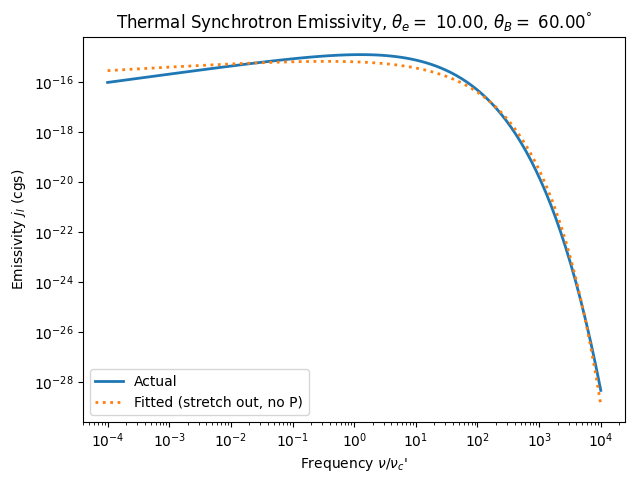

In [175]:
plt.figure(figsize=(7, 5))
plt.loglog(nuOvernucp, data, lw=2, label="Actual")
# plt.loglog(nuOvernucp, eval_model(emis_model, popt_basic, ind_var), lw=2, label="Fitted (basic)", ls='-')
# plt.loglog(nuOvernucp, eval_model(emis_model_stretch_out, popt_stretch_out0, ind_var), lw=2, label="Fitted (stretch out 0)", ls='--')
# plt.loglog(nuOvernucp, eval_model(emis_model_stretch_in, popt_stretch_in, ind_var), lw=2, label="Fitted (stretch in)", ls='--')
plt.loglog(nuOvernucp, eval_model(emis_model_stretch_out_noP, popt_stretch_out_noP, ind_var), lw=2, label="Fitted (stretch out, no P)", ls=':')
# plt.loglog(nuOvernucp, eval_model(emis_model_stretch_out, popt_stretch_out, ind_var), lw=2, label="Fitted (stretch out)", ls='--')
# plt.loglog(nuOvernucp, eval_model(emis_model_powerF, popt_powerF, ind_var), lw=2, label="Fitted (powerF)", ls=':')
# plt.loglog(nuOvernucp, eval_model(emis_model_power_exp, popt_pe, ind_var), lw=2, label="Fitted (power exp)", ls='-.')
# plt.loglog(nuOvernucp, emis_model(np.log10(ind_var), 13, C, -10), lw=2, label="By eye")
plt.xlabel(r"Frequency $\nu/\nu_c$'")
# plt.xscale('linear')
# plt.yscale('linear')
plt.ylabel(r'Emissivity $j_I$ (cgs)')
plt.title(fr'Thermal Synchrotron Emissivity, $\theta_e =$ {theta_eChange:.2f}, $\theta_B =$ {angle(theta_BChange):.2f}$^\degree$')
plt.legend(); plt.show()


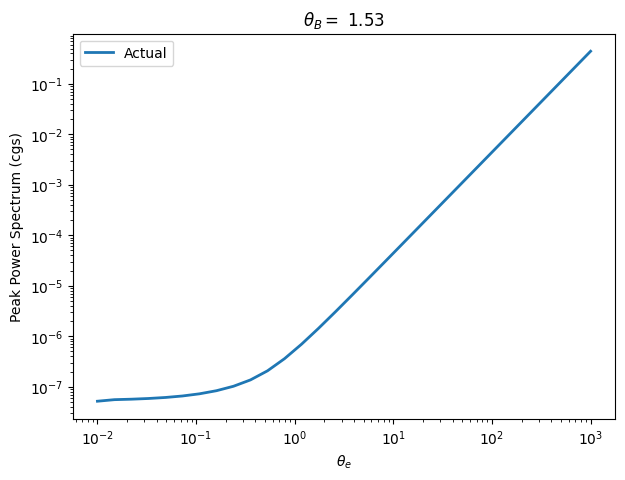

In [ ]:
#Flipped plot
plt.figure(figsize=(7, 5))
plt.plot(theta_es, peakPeaksPFlipped[1][0], lw=2, label=fr"Actual")
A_JS = 5e-11; C_JS = .4e0; delta_JS = 2.96; gam_JS = 1.17
# plt.plot(theta_es, emis_model(theta_es, A_JS, delta_JS, C_JS, gam_JS), lw=2, label=fr"Manual Fit",ls="dashed")
plt.title(fr"$\theta_B =$ {angle(theta_Bs[0]):.2f}$\degree$")
plt.yscale('log'); plt.xscale('log')
plt.xlabel(r"$\theta_e$"); plt.ylabel(fr'Peak Power Spectrum (cgs)')
plt.legend(); plt.show()

TODO: 

Figure out where I can apply fancy new peak_plot function

Full run-through of entire notebook and make sure things are symmetric/make sense/actually run

Check with AI about $\theta_B \to \pi$ and $0$ limits

Finally, figure out how to incorperate nu into my fitting functions, before smashing them together to approximate $j$